# Tarea 1 — Analisis Completo de Datos


In [12]:
# Manipulación de datos
import pandas as pd
import numpy as np 

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Análisis de nulos
import missingno as msno

import os
import re
from fuzzywuzzy import process

import warnings
warnings.filterwarnings('ignore')

import sys

In [13]:
#Importacion de libreria personalizada de exploración y limpieza de datos
ruta_biblioteca = r'C:\Users\diego\OneDrive\Escritorio\nuevo marketing_fintech\scripts'
sys.path.append(ruta_biblioteca)

import funciones_limpieza_y_analisis as mi_biblioteca   

In [2]:
pd.set_option('display.max_columns', None)

In [14]:
#Carga de datos
df_fintech = pd.read_csv(r"C:\Users\diego\OneDrive\Escritorio\nuevo marketing_fintech\bank-additional_bank-additional-full.csv", sep=";")

## Exploración inicial de los datos

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,age,0.0
1,job,0.0
2,marital,0.0
3,education,0.0
4,default,0.0
5,housing,0.0
6,loan,0.0
7,contact,0.0
8,month,0.0
9,day_of_week,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


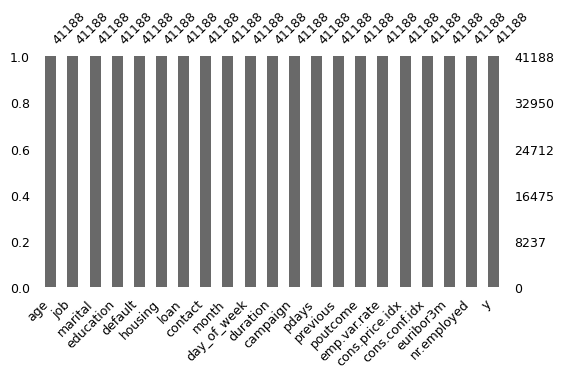

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


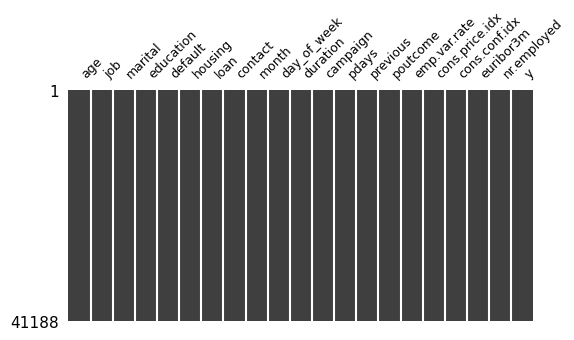

----------------------------------------------------------------------------------------------------
##Número de filas duplicadas (considerando todas las columnas)
	Hay 12 filas duplicadas.


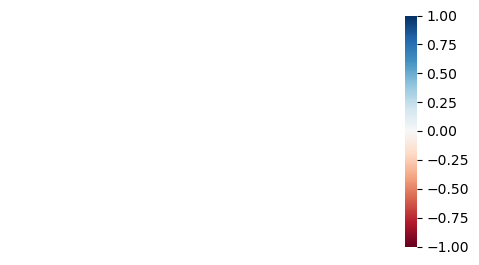

----------------------------------------------------------------------------------------------------
##########################################################################################


In [ ]:

mi_biblioteca.exploracion_inicial(df_fintech)

In [18]:
#Creación de una función de limpieza y transformación de datos en el dataset 

def limpieza_fintech(df_fintech):
    # 0. Copia para evitar avisos de memoria
    df_fintech = df_fintech.copy()
    
    # 1. Cambio de nombre de columnas
    df_fintech = df_fintech.rename(columns={
        'job':'job_type','marital':'marital_status','education':'education_level',
        'loan':'has_personal_loan','housing':'has_housing_loan','month':'contact_month',
        'day_of_week':'contact_day','contact':'contact_method','duration':'call_duration',
        'default':'credit_default','campaign':'contact_attempts','pdays':'previously_contacted',
        'previous':'previous_contacts','poutcome':'previous_campaign_outcome','y':'subscribed',
        'euribor3m':'euribor_3m_rate','nr.employed':'total_employment',
        'cons.price.idx':'consumer_price_index','emp.var.rate':'employment_variation_rate',
        'cons.conf.idx':'consumer_confidence_index'
    })

    #Reemplazar 'unknown' por 'undisclosed' ---
    cols_to_fix = ['job_type', 'marital_status', 'education_level', 'credit_default']
    df_fintech[cols_to_fix] = df_fintech[cols_to_fix].replace('unknown', 'undisclosed')
    # ----------------------------------------------------------

    
    # 2. Eliminar duplicados (excluyendo la variable objetivo)
    columnas_duplicados = [c for c in df_fintech.columns if c != 'subscribed']
    df_fintech = df_fintech.drop_duplicates(subset=columnas_duplicados)

    # 3. Agrupación de duración de llamadas
    df_fintech["call_duration_group"] = pd.cut(
        df_fintech["call_duration"], 
        bins=[-1, 60, 180, 300, 600, 1200, 10000],
        labels=["0-1 min", "2-3 min", "4-5 min", "6-10 min", "11-20 min", "21+ min"],
        right=True
    )
    
    # 4. Categorical ordenados
    orden_meses = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    df_fintech['contact_month'] = pd.Categorical(df_fintech['contact_month'], categories=orden_meses, ordered=True)
    
    orden_dias = ['mon', 'tue', 'wed', 'thu', 'fri']
    df_fintech['contact_day'] = pd.Categorical(df_fintech['contact_day'], categories=orden_dias, ordered=True)
    
    # 5. Eliminar filas con 'unknown' en préstamos (estos se mantienen como 'unknown' para ser eliminados)
    df_fintech = df_fintech[(df_fintech["has_housing_loan"] != "unknown") & (df_fintech["has_personal_loan"] != "unknown")]
    
    # 6. Nuevas columnas
    df_fintech['is_new_campaign_client'] = (df_fintech['previous_contacts'] == 0).map({True: 'yes', False: 'no'})
    df_fintech['high_contact_attempts'] = (df_fintech['contact_attempts'] > 3).map({True: 'yes', False: 'no'})
    
    # 7. Reordenar columna objetivo al final
    if 'subscribed' in df_fintech.columns:
        col_subscribed = df_fintech.pop('subscribed')
        df_fintech['subscribed'] = col_subscribed

    return df_fintech


In [19]:
df_fintech_clean = limpieza_fintech(df_fintech)
df_fintech_clean.sample(5)

,age,job_type,marital_status,education_level,credit_default,has_housing_loan,has_personal_loan,contact_method,contact_month,contact_day,call_duration,contact_attempts,previously_contacted,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,total_employment,call_duration_group,is_new_campaign_client,high_contact_attempts,subscribed
32106,45,technician,married,basic.9y,no,no,yes,cellular,may,fri,1077,1,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,11-20 min,yes,no,yes
6217,34,blue-collar,married,basic.9y,undisclosed,no,yes,telephone,may,tue,107,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,2-3 min,yes,no,no
9946,41,housemaid,married,basic.4y,undisclosed,no,no,telephone,jun,wed,105,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,2-3 min,yes,no,no
18607,47,technician,married,professional.course,no,no,no,cellular,jul,thu,223,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,4-5 min,yes,no,no
26680,34,self-employed,married,illiterate,no,yes,no,cellular,nov,thu,51,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0-1 min,yes,no,no


## EDA

### Análisis Univariable

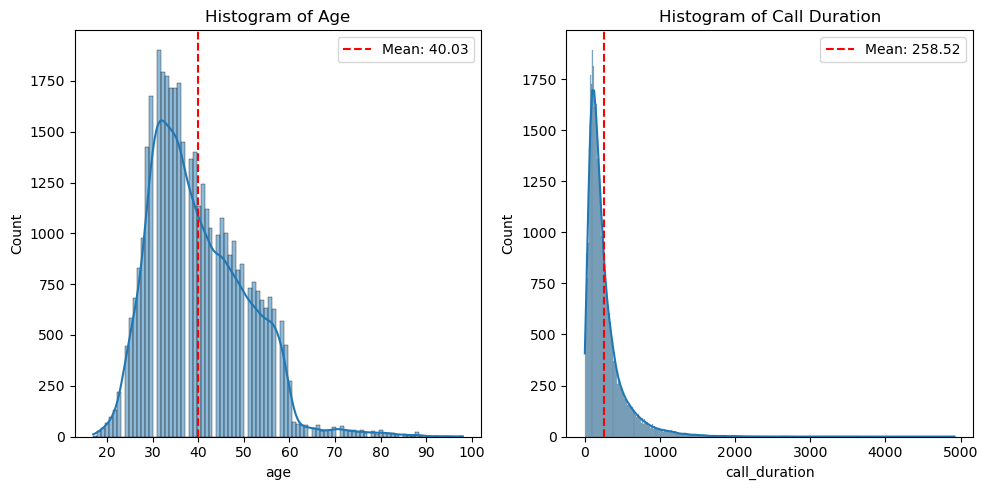

In [20]:
import seaborn as sns

import matplotlib.pyplot as plt

# Histogram for 'age' with mean line
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_fintech_clean['age'], kde=True)
plt.axvline(df_fintech_clean['age'].mean(), color='red', linestyle='--', label=f'Mean: {df_fintech_clean["age"].mean():.2f}')
plt.title('Histogram of Age')
plt.legend()

# Histogram for 'call_duration' with mean line
plt.subplot(1, 2, 2)
sns.histplot(df_fintech_clean['call_duration'], kde=True)
plt.axvline(df_fintech_clean['call_duration'].mean(), color='red', linestyle='--', label=f'Mean: {df_fintech_clean["call_duration"].mean():.2f}')
plt.title('Histogram of Call Duration')
plt.legend()

plt.tight_layout()
plt.show()

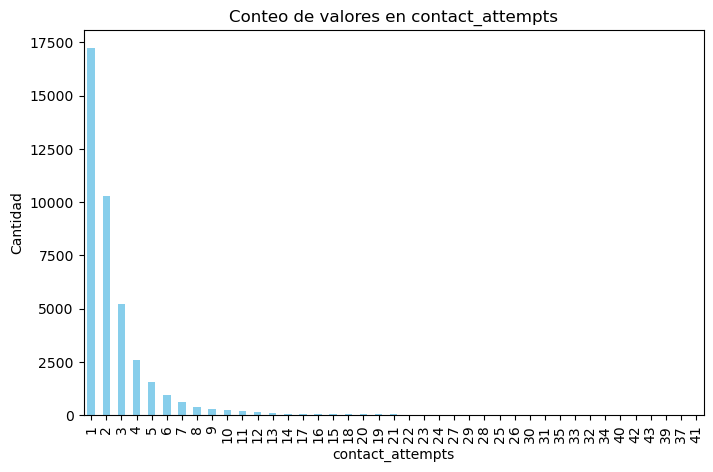

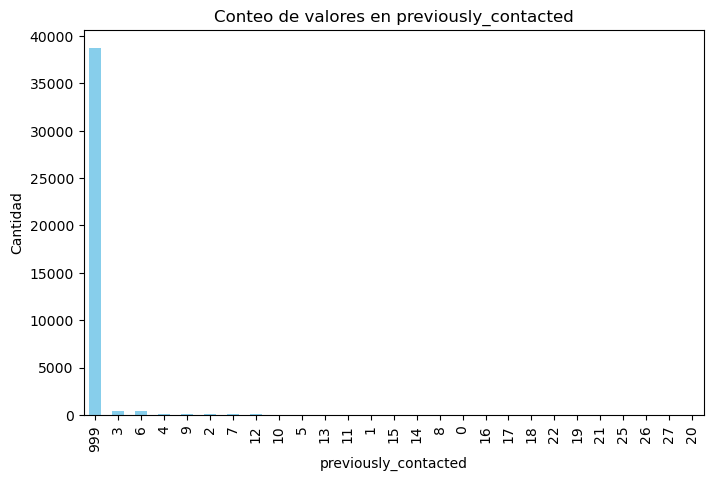

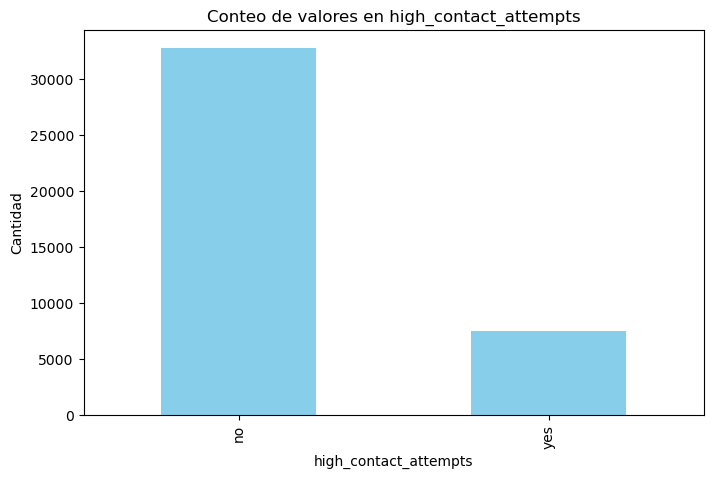

In [21]:
# Columnas a graficar
columnas = [
    'contact_attempts',
    'previously_contacted',
    'high_contact_attempts'
]

# Iteramos por cada columna para graficar
for col in columnas:
    plt.figure(figsize=(8, 5))
    
    # Contamos los valores de la columna
    conteo = df_fintech_clean[col].value_counts()
    
    # Creamos el gráfico de barras
    conteo.plot(kind='bar', color='skyblue')
    
    # Añadimos título y etiquetas
    plt.title(f'Conteo de valores en {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    
    # Mostramos el gráfico
    plt.show()

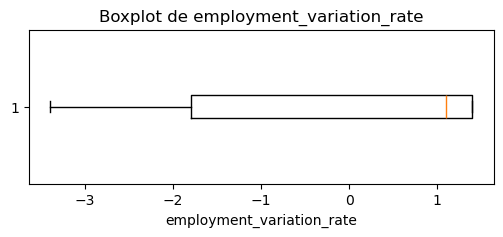

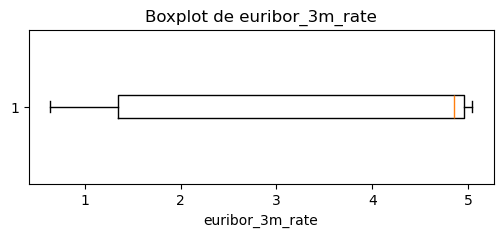

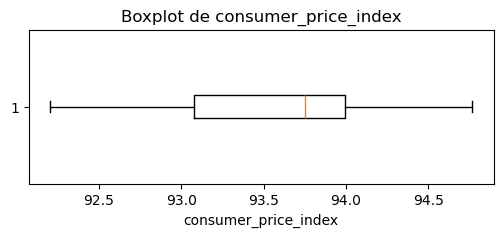

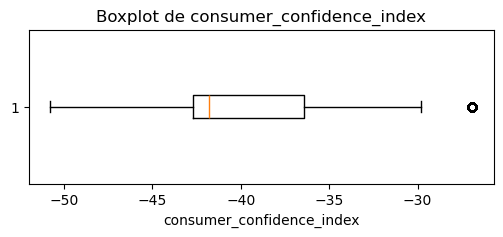

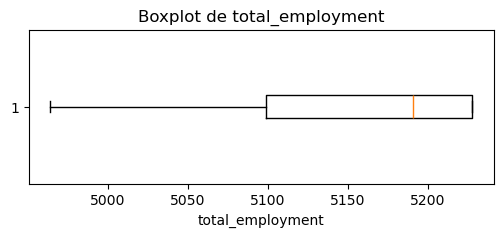

In [25]:
import matplotlib.pyplot as plt


columnas = [
    'employment_variation_rate',
    'euribor_3m_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'total_employment'
]

for col in columnas:
    data = df_fintech_clean[col].dropna()
    
    
    # Boxplot
    plt.figure(figsize=(6,2))
    plt.boxplot(data, vert=False)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col if col != 'consumer_price_index' else f'{col}')
    plt.show()

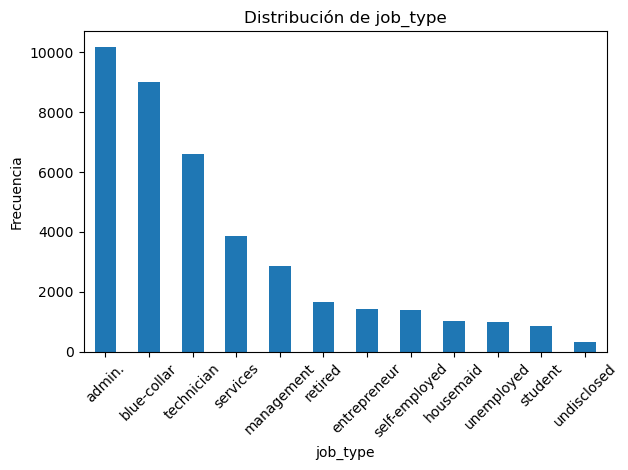

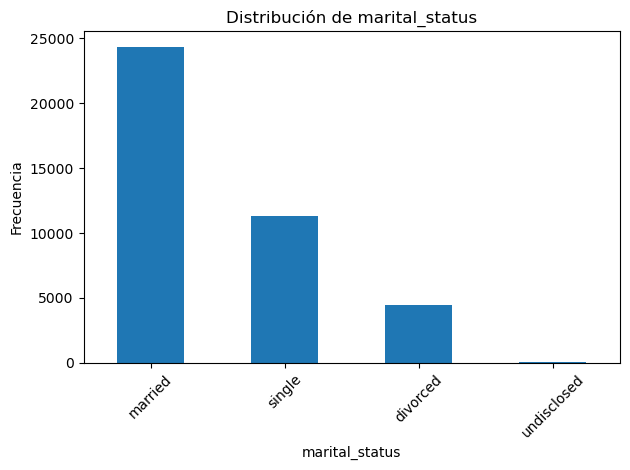

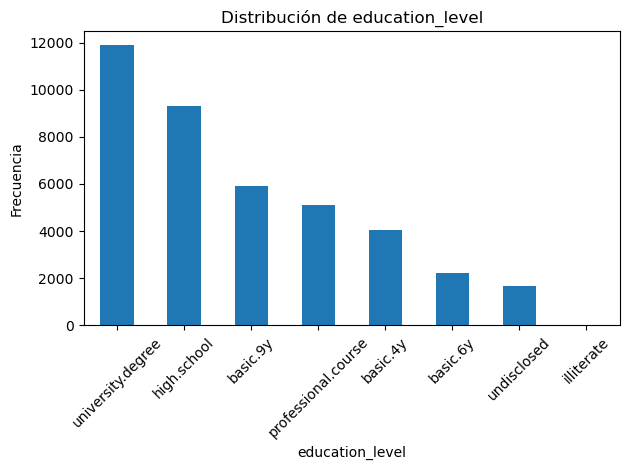

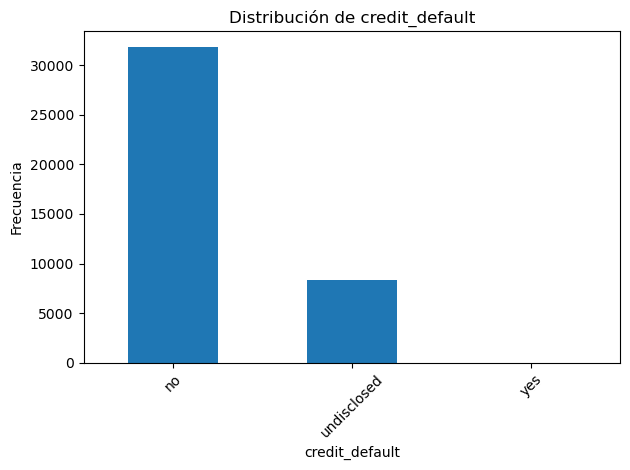

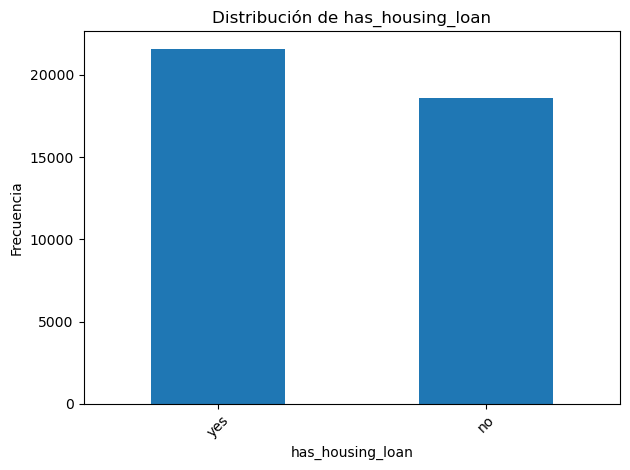

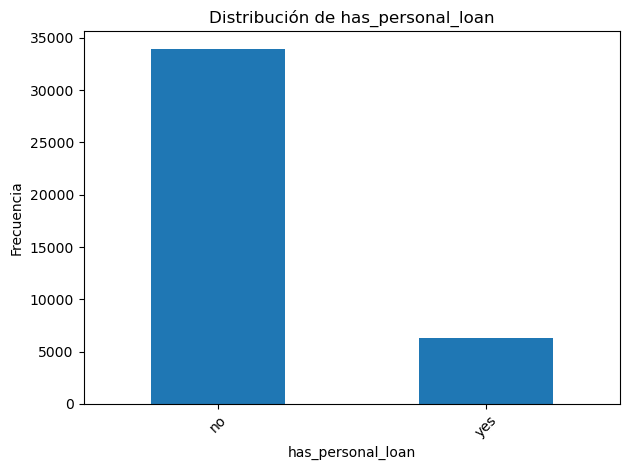

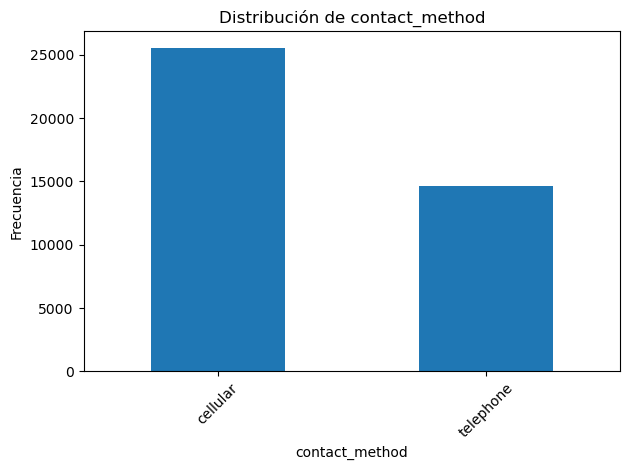

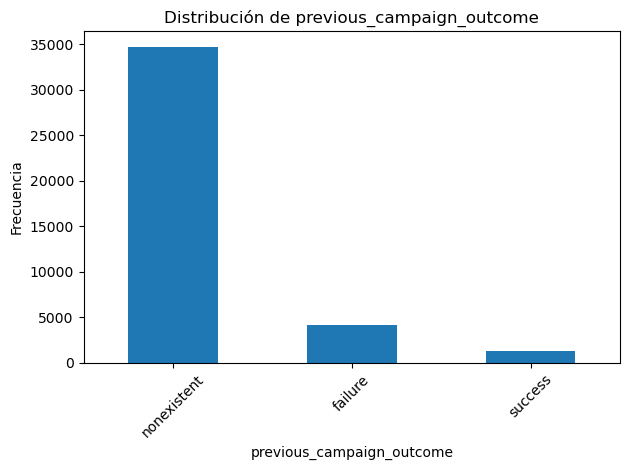

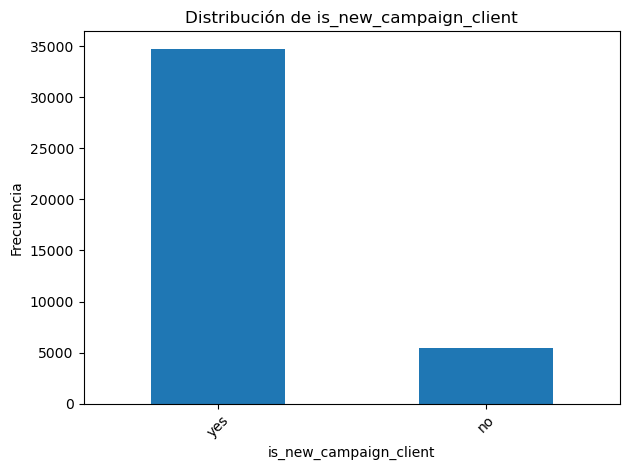

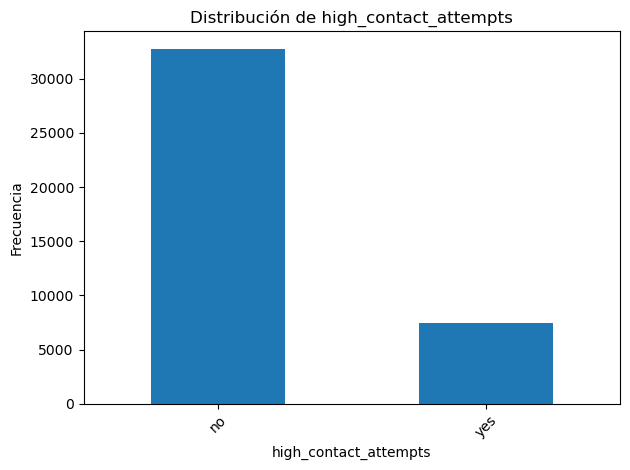

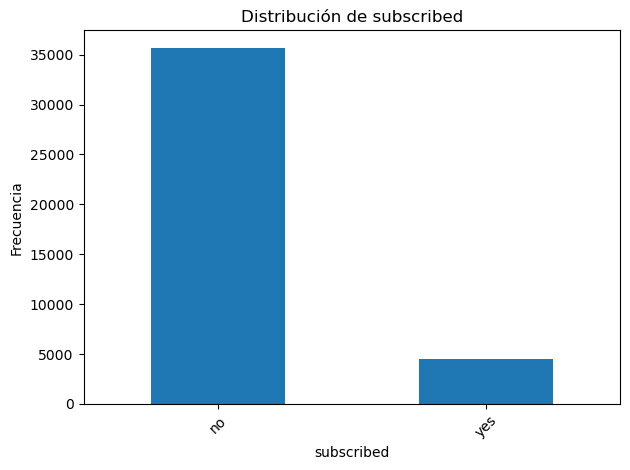

In [26]:
columnas = df_fintech_clean.select_dtypes(include='object').columns.tolist()

for col in columnas:
    plt.figure()
    df_fintech_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Análisis Bivariable



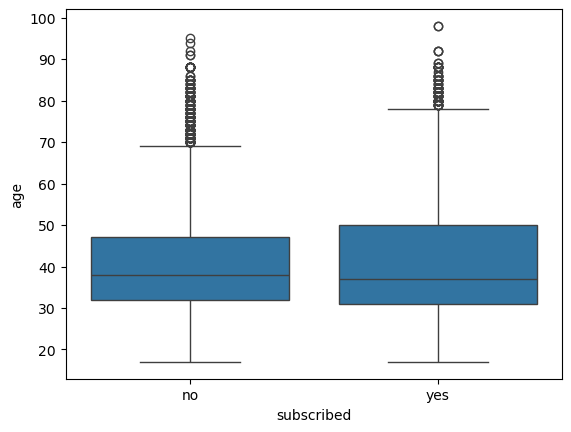

In [27]:
variable_dependiente = 'subscribed'
variable_independiente = 'age'
sns.boxplot(data = df_fintech_clean, y = variable_independiente, x = variable_dependiente)
plt.show()

### Probabilidades de contratar segun otras variables

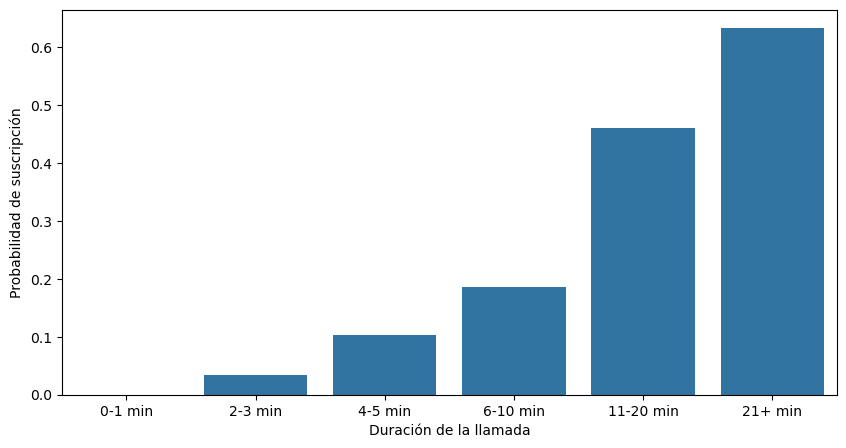

In [31]:

df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('call_duration_group')['subscribed_num'].mean()

plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Duración de la llamada")

plt.show()

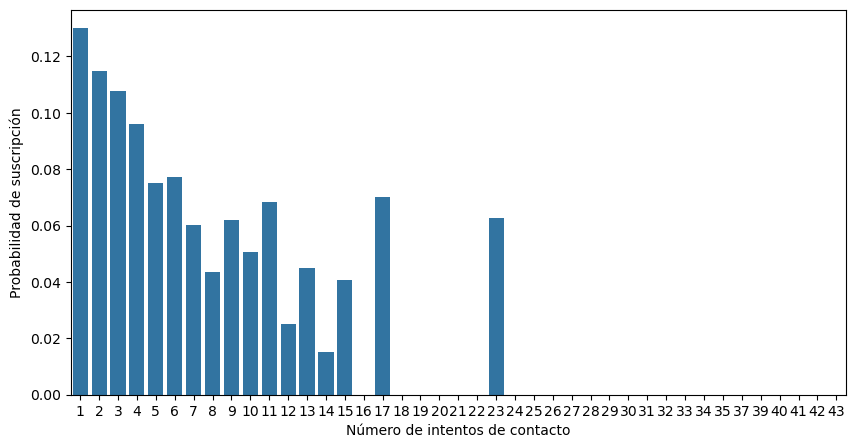

In [32]:

df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('contact_attempts')['subscribed_num'].mean()

plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Número de intentos de contacto")

plt.show()

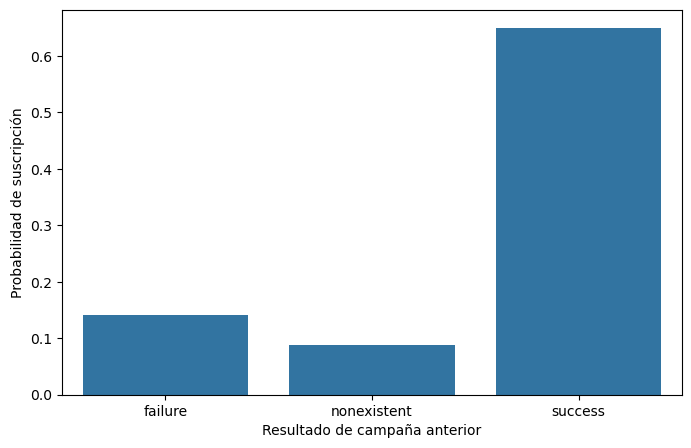

In [33]:

# convertir yes/no a 1/0
df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})

# calcular probabilidad de suscripción por resultado de campaña anterior
success_rate = df_fintech_clean.groupby('previous_campaign_outcome')['subscribed_num'].mean()

# gráfico
plt.figure(figsize=(8,5))

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Resultado de campaña anterior")

plt.show()

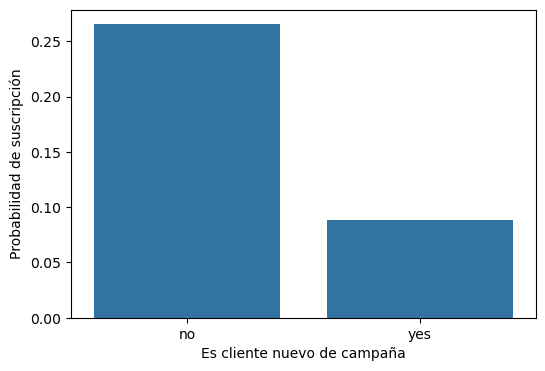

In [34]:
# Calcular probabilidad
success_rate_new = df_fintech_clean.groupby('is_new_campaign_client')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_new.index,
    y=success_rate_new.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Es cliente nuevo de campaña")

plt.show()

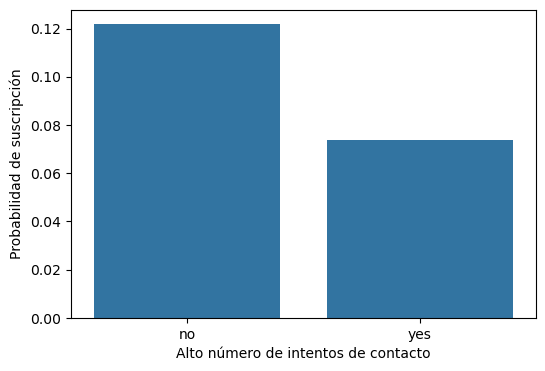

In [35]:
# Calcular probabilidad
success_rate_high = df_fintech_clean.groupby('high_contact_attempts')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_high.index,
    y=success_rate_high.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Alto número de intentos de contacto")

plt.show()

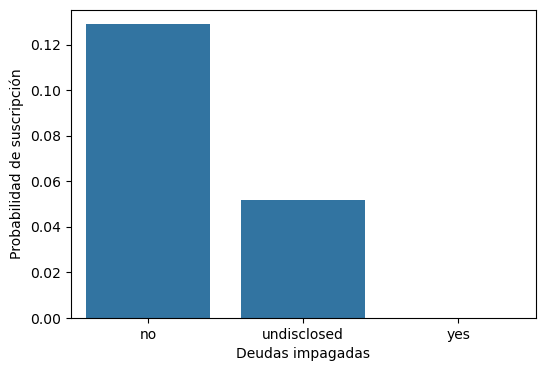

In [36]:
# Calcular probabilidad
success_rate_high = df_fintech_clean.groupby('credit_default')['subscribed_num'].mean()

# Gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=success_rate_high.index,
    y=success_rate_high.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Deudas impagadas")

plt.show()

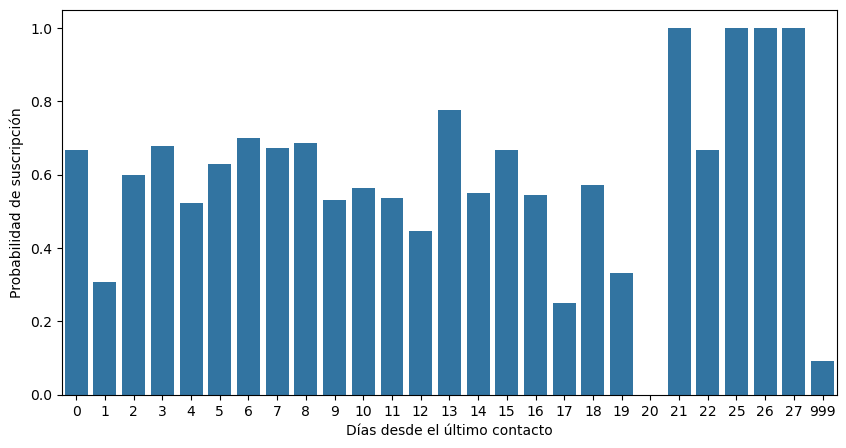

In [37]:
df_fintech_clean['subscribed_num'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('previously_contacted')['subscribed_num'].mean()

plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción")
plt.xlabel("Días desde el último contacto")

plt.show()

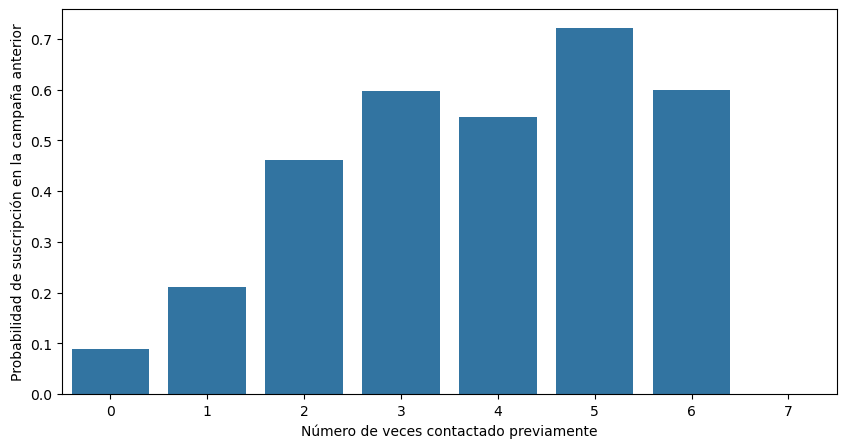

In [38]:
df_fintech_clean['previous_campaign_outcome'] = df_fintech_clean['subscribed'].map({'yes':1, 'no':0})
success_rate = df_fintech_clean.groupby('previous_contacts')['subscribed_num'].mean()


plt.figure(figsize=(10,5))  # más ancho → más separación visual

sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.ylabel("Probabilidad de suscripción en la campaña anterior")
plt.xlabel("Número de veces contactado previamente")

plt.show()

In [39]:
variable_dependiente = 'previous_campaign_outcome'
variable_independiente = 'previous_contacts'

pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente])

previous_campaign_outcome,0,1
previous_contacts,,
0,31623,3077
1,3512,939
2,397,339
3,84,125
4,30,36
5,5,13
6,2,3
7,1,0


### Variables macroeconomicas

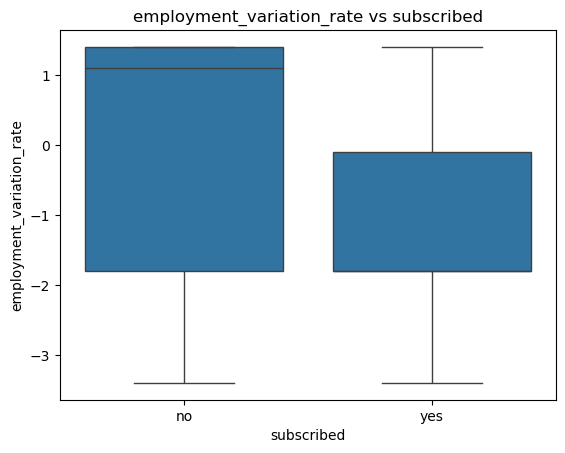

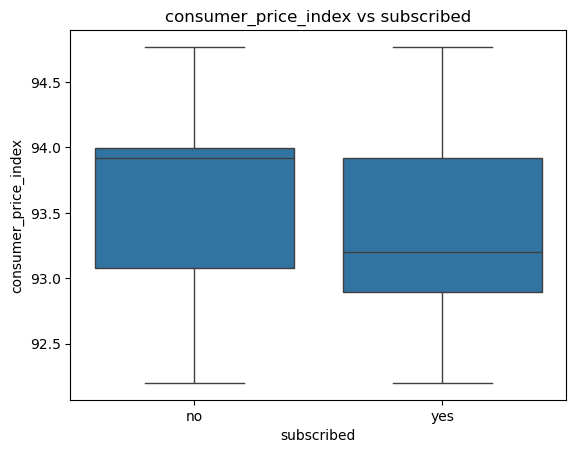

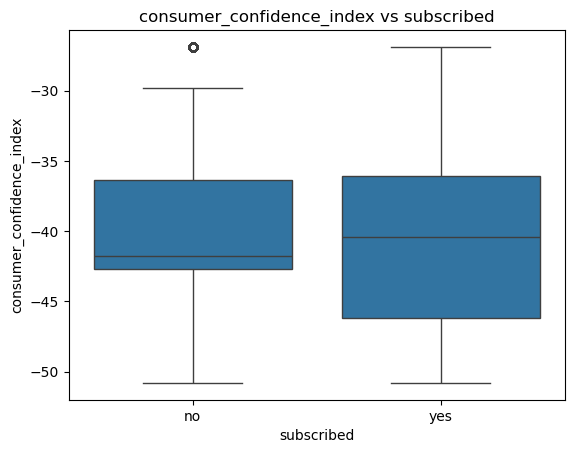

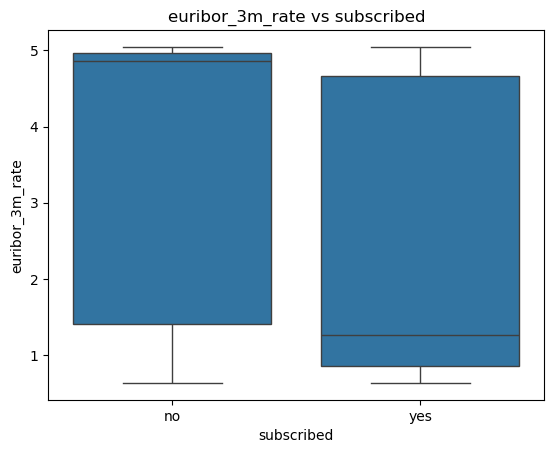

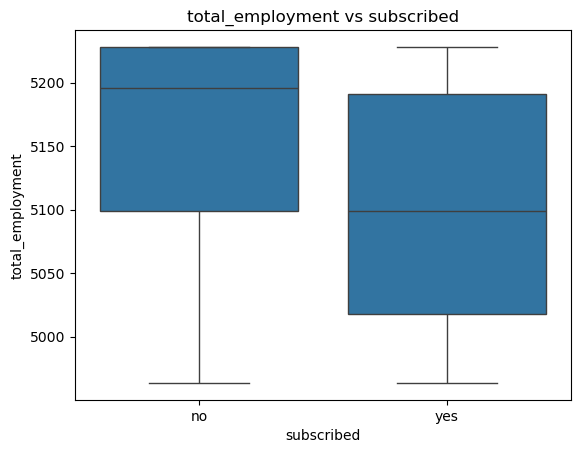

In [41]:
variables = [
    'employment_variation_rate',
    'consumer_price_index',
    'consumer_confidence_index',
    'euribor_3m_rate',
    'total_employment'
]

for var in variables:
    plt.figure()
    
    sns.boxplot(data=df_fintech_clean, x='subscribed', y=var)
    
    plt.title(f'{var} vs subscribed')
    plt.show()

### Tablas de contingencia con variables categóricas


In [42]:
variable_dependiente = 'subscribed'
variable_independiente = 'job_type'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
job_type,,,
admin.,22.07,3.29,25.36
blue-collar,20.88,1.55,22.43
entrepreneur,3.23,0.30,3.53
housemaid,2.31,0.26,2.57
management,6.29,0.81,7.10
retired,3.11,1.06,4.17
self-employed,3.07,0.37,3.44
services,8.83,0.79,9.62
student,1.46,0.66,2.12


In [43]:
variable_dependiente = 'subscribed'
variable_independiente = 'marital_status'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
marital_status,,,
divorced,10.01,1.16,11.17
married,54.40,6.15,60.55
single,24.15,3.93,28.08
undisclosed,0.17,0.03,0.20
All,88.72,11.28,100.00


In [44]:
variable_dependiente = 'subscribed'
variable_independiente = 'education_level'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
education_level,,,
basic.4y,9.06,1.04,10.10
basic.6y,5.10,0.45,5.55
basic.9y,13.52,1.14,14.67
high.school,20.61,2.51,23.12
illiterate,0.03,0.01,0.04
professional.course,11.29,1.44,12.73
undisclosed,3.59,0.61,4.21
university.degree,25.51,4.07,29.58
All,88.72,11.28,100.00


In [45]:
variable_dependiente = 'subscribed'
variable_independiente = 'has_housing_loan'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
has_housing_loan,,,
no,41.28,5.04,46.32
yes,47.44,6.24,53.68
All,88.72,11.28,100.00


In [46]:
variable_dependiente = 'subscribed'
variable_independiente = 'has_personal_loan'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
has_personal_loan,,,
no,74.87,9.58,84.45
yes,13.85,1.70,15.55
All,88.72,11.28,100.00


In [47]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_method'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_method,,,
cellular,54.28,9.36,63.64
telephone,34.44,1.92,36.36
All,88.72,11.28,100.00


In [48]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_month'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_month,,,
mar,0.65,0.67,1.33
apr,5.10,1.30,6.40
may,31.23,2.16,33.39
jun,11.43,1.36,12.80
jul,15.89,1.58,17.47
aug,13.46,1.59,15.05
sep,0.76,0.61,1.38
oct,0.97,0.76,1.73
nov,9.00,1.02,10.01


In [49]:
variable_dependiente = 'subscribed'
variable_independiente = 'contact_day'


pd.crosstab(df_fintech_clean[variable_independiente], 
            df_fintech_clean[variable_dependiente], 
            margins=True,
            normalize = True).mul(100).round(2)

subscribed,no,yes,All
contact_day,,,
mon,18.64,2.06,20.71
tue,17.30,2.30,19.60
wed,17.43,2.32,19.75
thu,18.44,2.53,20.97
fri,16.91,2.06,18.97
All,88.72,11.28,100.00
